# Kosh-AI: NSAP Scheme Demand & Digital Inclusion Analysis
### District-Level Machine Learning on the AI Kosh NSAP Dataset

This notebook works entirely with **`Social Welfare Schemes.csv`** (the AI Kosh NSAP dataset, FY 2025–2026) and covers the full workflow in one place:

1. **Data Loading & Initial Inspection**
2. **Data Cleaning**
3. **Feature Engineering** (ratios derived from raw counts)
4. **Exploratory Data Analysis / Visualization**
5. **Problem Statement A — Scheme Pattern Classification**
   Predict `schemecode` (IGNOAPS / IGNWPS / IGNDPS) from a district-scheme record's demographic composition.
6. **Problem Statement C — Digital Inclusion Gap Analysis**
   Predict Aadhaar/mobile-linkage rates and flag districts at risk of low digital inclusion for DBT (Direct Benefit Transfer) readiness.
7. **Conclusions & Next Steps**

> **Scope note:** This dataset is aggregated at the **district × scheme** level (beneficiary counts), not individual-applicant level. All modeling here operates on that granularity — predictions describe *scheme-record patterns and digital-inclusion risk at the district level*, not individual eligibility. See the Responsible-AI note in the final section.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## 2. Data Loading & Initial Inspection

Place `Social Welfare Schemes.csv` in the same directory as this notebook (or update the path below) before running.

In [2]:
CSV_PATH = "Social Welfare Schemes.csv"
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
df.head()


Shape: (2156, 16)


,finyear,lgdstatecode,statename,lgddistrictcode,districtname,schemecode,totalbeneficiaries,totalmale,totalfemale,totaltransgender,totalsc,totalst,totalgen,totalobc,totalaadhaar,totalmobilenumber
0,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNDPS,108,72,36,0,0,3,104,1,108,69
1,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNOAPS,8438,5059,3379,0,37,235,8083,83,8371,7190
2,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNWPS,202,0,202,0,1,15,180,6,200,159
3,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNDPS,310,211,99,0,0,77,200,33,234,110
4,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNOAPS,5958,3958,2000,0,2,1347,4367,242,3875,2287


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2156 entries, 0 to 2155
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   finyear             2156 non-null   str  
 1   lgdstatecode        2156 non-null   int64
 2   statename           2156 non-null   str  
 3   lgddistrictcode     2156 non-null   int64
 4   districtname        2156 non-null   str  
 5   schemecode          2156 non-null   str  
 6   totalbeneficiaries  2156 non-null   int64
 7   totalmale           2156 non-null   int64
 8   totalfemale         2156 non-null   int64
 9   totaltransgender    2156 non-null   int64
 10  totalsc             2156 non-null   int64
 11  totalst             2156 non-null   int64
 12  totalgen            2156 non-null   int64
 13  totalobc            2156 non-null   int64
 14  totalaadhaar        2156 non-null   int64
 15  totalmobilenumber   2156 non-null   int64
dtypes: int64(12), str(4)
memory usage: 269.6 KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
finyear,2156,1,2025-2026,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lgdstatecode,2156.0,NaN,NaN,NaN,18.085807,9.770668,1.0,9.0,19.0,24.0,38.0
statename,2156,36,UTTAR PRADESH,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lgddistrictcode,2156.0,NaN,NaN,NaN,366.853432,211.760095,1.0,185.0,365.0,546.25,763.0
districtname,2156,726,BILASPUR,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
schemecode,2156,3,IGNOAPS,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
totalbeneficiaries,2156.0,NaN,NaN,NaN,13864.290353,22855.917172,2.0,961.75,4702.5,17377.0,278410.0
totalmale,2156.0,NaN,NaN,NaN,5518.308442,11926.748715,0.0,0.0,503.0,4819.5,130524.0
totalfemale,2156.0,NaN,NaN,NaN,8344.925325,12518.941254,1.0,418.75,3415.0,11514.75,147780.0
totaltransgender,2156.0,NaN,NaN,NaN,0.926716,6.692879,0.0,0.0,0.0,0.0,165.0


In [5]:
print("Unique financial years:", df["finyear"].unique())
print("Unique scheme codes:", df["schemecode"].unique())
print("Number of states/UTs:", df["statename"].nunique())
print("Number of districts:", df["districtname"].nunique())
print("Total records:", len(df))


Unique financial years: <StringArray>
['2025-2026']
Length: 1, dtype: str
Unique scheme codes: <StringArray>
['IGNDPS', 'IGNOAPS', 'IGNWPS']
Length: 3, dtype: str
Number of states/UTs: 36
Number of districts: 726
Total records: 2156


## 3. Data Cleaning

Steps performed:
- Check and handle missing values
- Check and remove exact duplicate rows
- Standardize text columns (state/district names) for consistent grouping
- Validate that demographic sub-counts are consistent with `totalbeneficiaries`
- Check for and handle any zero/negative anomalies in count columns


In [6]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [7]:
# Duplicate rows
dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)


Exact duplicate rows: 0


In [8]:
# Standardize text fields
df["statename"] = df["statename"].str.strip().str.upper()
df["districtname"] = df["districtname"].str.strip().str.upper()
df["schemecode"] = df["schemecode"].str.strip().str.upper()

df[["statename", "districtname", "schemecode"]].head()


,statename,districtname,schemecode
0,JAMMU AND KASHMIR,ANANTNAG,IGNDPS
1,JAMMU AND KASHMIR,ANANTNAG,IGNOAPS
2,JAMMU AND KASHMIR,ANANTNAG,IGNWPS
3,JAMMU AND KASHMIR,POONCH,IGNDPS
4,JAMMU AND KASHMIR,POONCH,IGNOAPS


In [9]:
# Consistency check: do gender sub-counts sum to totalbeneficiaries?
count_cols = ["totalmale", "totalfemale", "totaltransgender"]
df["_gender_sum_check"] = df[count_cols].sum(axis=1)
mismatch = df[df["_gender_sum_check"] != df["totalbeneficiaries"]]
print(f"Rows where gender sub-counts don't sum to totalbeneficiaries: {len(mismatch)} / {len(df)}")

# Same check for social category
cat_cols = ["totalsc", "totalst", "totalgen", "totalobc"]
df["_category_sum_check"] = df[cat_cols].sum(axis=1)
mismatch_cat = df[df["_category_sum_check"] != df["totalbeneficiaries"]]
print(f"Rows where category sub-counts don't sum to totalbeneficiaries: {len(mismatch_cat)} / {len(df)}")

df = df.drop(columns=["_gender_sum_check", "_category_sum_check"])


Rows where gender sub-counts don't sum to totalbeneficiaries: 12 / 2156
Rows where category sub-counts don't sum to totalbeneficiaries: 165 / 2156


In [10]:
# Check for non-positive totalbeneficiaries (would break ratio features)
zero_or_neg = (df["totalbeneficiaries"] <= 0).sum()
print(f"Rows with totalbeneficiaries <= 0: {zero_or_neg}")

# Drop them if present (a district-scheme record with 0 beneficiaries carries no usable demographic signal)
if zero_or_neg > 0:
    df = df[df["totalbeneficiaries"] > 0].reset_index(drop=True)
    print("Rows dropped. New shape:", df.shape)


Rows with totalbeneficiaries <= 0: 0


In [11]:
df.isnull().sum().sum(), df.duplicated().sum()


(np.int64(0), np.int64(0))

## 4. Feature Engineering

Raw beneficiary counts are converted into **ratios**, which carry the actual demographic *composition* signal (and generalize across districts of very different total population sizes, unlike raw counts):

| Engineered Feature | Formula |
|---|---|
| `male_ratio` / `female_ratio` / `transgender_ratio` | gender count ÷ totalbeneficiaries |
| `sc_ratio` / `st_ratio` / `gen_ratio` / `obc_ratio` | social category count ÷ totalbeneficiaries |
| `aadhaar_rate` | totalaadhaar ÷ totalbeneficiaries |
| `mobile_rate` | totalmobilenumber ÷ totalbeneficiaries |


In [12]:
df["male_ratio"] = df["totalmale"] / df["totalbeneficiaries"]
df["female_ratio"] = df["totalfemale"] / df["totalbeneficiaries"]
df["transgender_ratio"] = df["totaltransgender"] / df["totalbeneficiaries"]

df["sc_ratio"] = df["totalsc"] / df["totalbeneficiaries"]
df["st_ratio"] = df["totalst"] / df["totalbeneficiaries"]
df["gen_ratio"] = df["totalgen"] / df["totalbeneficiaries"]
df["obc_ratio"] = df["totalobc"] / df["totalbeneficiaries"]

df["aadhaar_rate"] = (df["totalaadhaar"] / df["totalbeneficiaries"]).clip(upper=1.0)
df["mobile_rate"] = (df["totalmobilenumber"] / df["totalbeneficiaries"]).clip(upper=1.0)

engineered_cols = ["male_ratio", "female_ratio", "transgender_ratio",
                    "sc_ratio", "st_ratio", "gen_ratio", "obc_ratio",
                    "aadhaar_rate", "mobile_rate"]
df[engineered_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
male_ratio,2156.0,0.381757,0.286901,0.000000,0.000000,0.497715,0.621321,0.933099
female_ratio,2156.0,0.618160,0.286967,0.066901,0.378363,0.502269,1.000000,1.000000
transgender_ratio,2156.0,0.000081,0.002227,0.000000,0.000000,0.000000,0.000000,0.103189
sc_ratio,2156.0,0.141731,0.112750,0.000000,0.044487,0.130009,0.220412,0.681014
st_ratio,2156.0,0.191598,0.303259,0.000000,0.003424,0.038037,0.226209,1.000000
gen_ratio,2156.0,0.392874,0.311478,0.000000,0.121624,0.309574,0.643166,1.000000
obc_ratio,2156.0,0.273577,0.236721,0.000000,0.027119,0.241015,0.472532,0.999845
aadhaar_rate,2156.0,0.794696,0.239127,0.000000,0.696087,0.882334,0.978039,1.000000
mobile_rate,2156.0,0.621536,0.315275,0.000000,0.388963,0.706061,0.903779,1.000000


## 5. Exploratory Data Analysis

### 5.1 Scheme Distribution

schemecode
IGNOAPS    731
IGNWPS     723
IGNDPS     702
Name: count, dtype: int64


/tmp/ipykernel_532/559510208.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=scheme_counts.index, y=scheme_counts.values, palette="Blues_d")


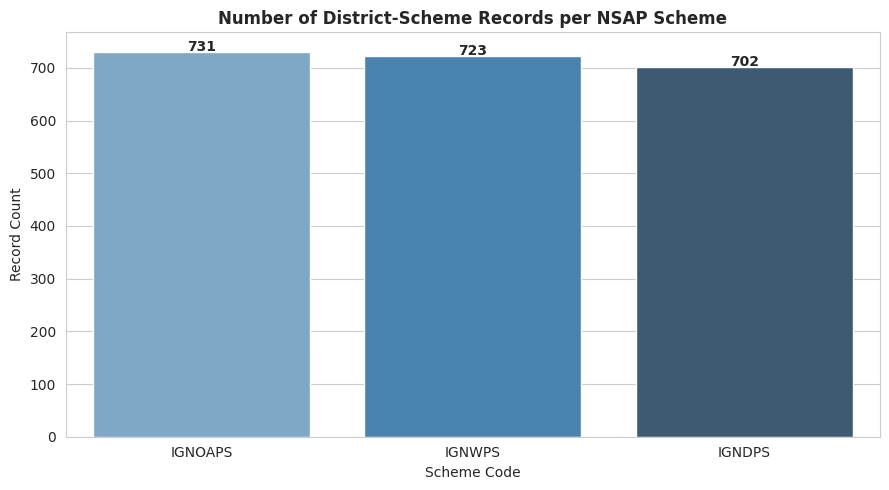

In [13]:
scheme_counts = df["schemecode"].value_counts()
print(scheme_counts)

plt.figure()
ax = sns.barplot(x=scheme_counts.index, y=scheme_counts.values, palette="Blues_d")
ax.set_title("Number of District-Scheme Records per NSAP Scheme")
ax.set_xlabel("Scheme Code")
ax.set_ylabel("Record Count")
for i, v in enumerate(scheme_counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


### 5.2 Total Beneficiaries by Scheme

/tmp/ipykernel_532/1740969618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="schemecode", y="totalbeneficiaries", palette="Set2")


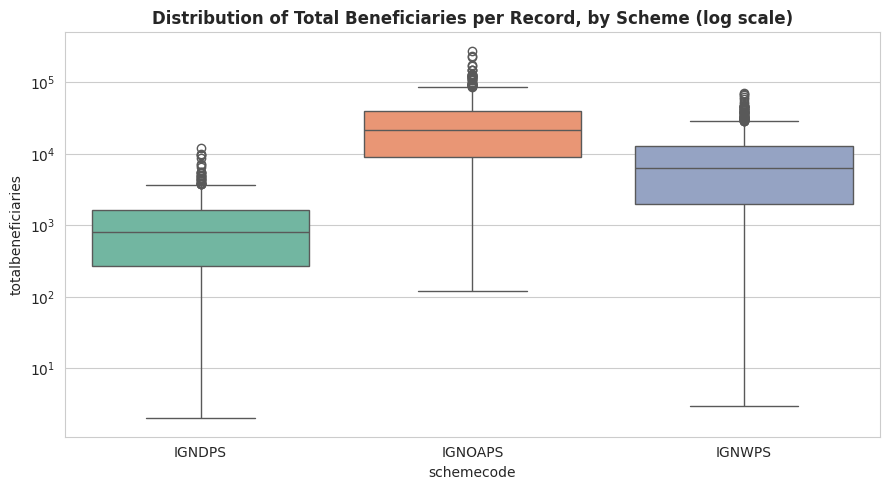

In [14]:
plt.figure()
ax = sns.boxplot(data=df, x="schemecode", y="totalbeneficiaries", palette="Set2")
ax.set_yscale("log")
ax.set_title("Distribution of Total Beneficiaries per Record, by Scheme (log scale)")
plt.tight_layout()
plt.show()


### 5.3 Top 15 States by Total Beneficiaries

/tmp/ipykernel_532/3203746176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=state_totals.values, y=state_totals.index, palette="viridis")


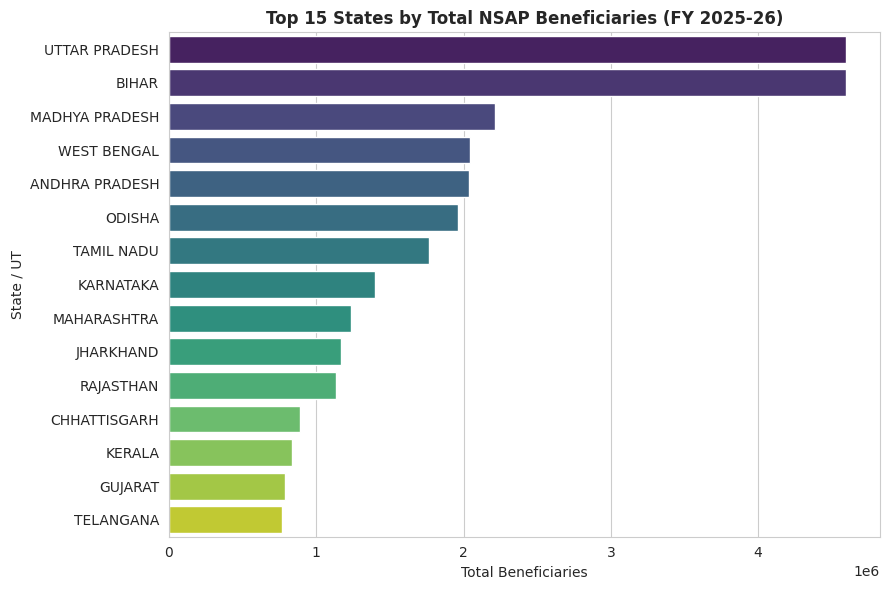

In [15]:
state_totals = df.groupby("statename")["totalbeneficiaries"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
ax = sns.barplot(x=state_totals.values, y=state_totals.index, palette="viridis")
ax.set_title("Top 15 States by Total NSAP Beneficiaries (FY 2025-26)")
ax.set_xlabel("Total Beneficiaries")
ax.set_ylabel("State / UT")
plt.tight_layout()
plt.show()


### 5.4 Gender Composition by Scheme

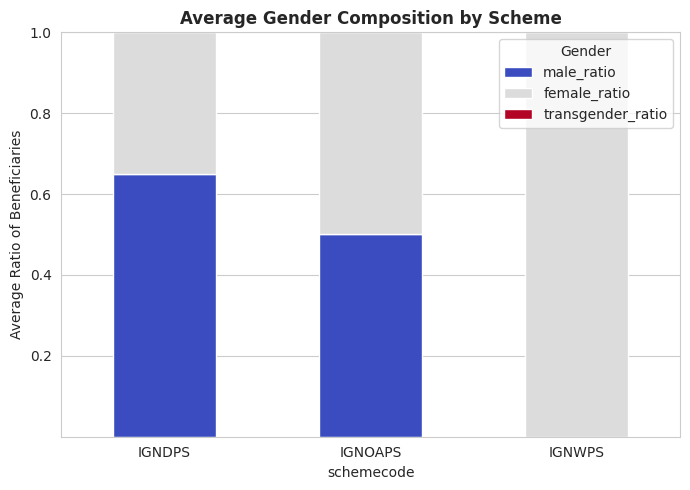

In [16]:
gender_by_scheme = df.groupby("schemecode")[["male_ratio", "female_ratio", "transgender_ratio"]].mean()
gender_by_scheme.plot(kind="bar", stacked=True, figsize=(7, 5), colormap="coolwarm")
plt.title("Average Gender Composition by Scheme")
plt.ylabel("Average Ratio of Beneficiaries")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


### 5.5 Social Category Composition by Scheme

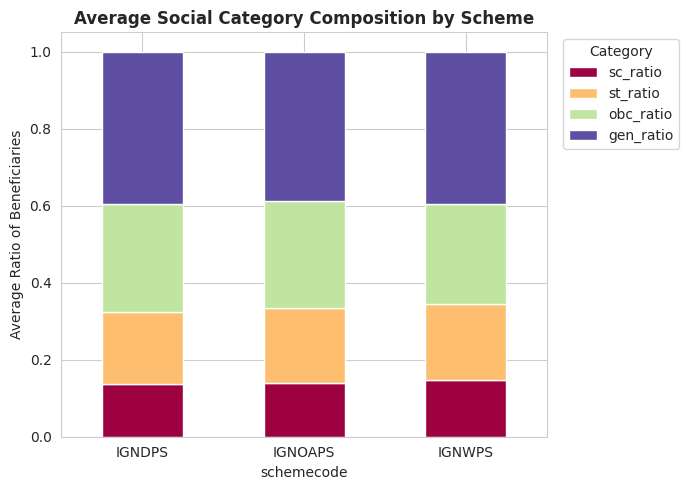

In [17]:
cat_by_scheme = df.groupby("schemecode")[["sc_ratio", "st_ratio", "obc_ratio", "gen_ratio"]].mean()
cat_by_scheme.plot(kind="bar", stacked=True, figsize=(7, 5), colormap="Spectral")
plt.title("Average Social Category Composition by Scheme")
plt.ylabel("Average Ratio of Beneficiaries")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 5.6 Digital Inclusion: Aadhaar & Mobile Linkage Rates

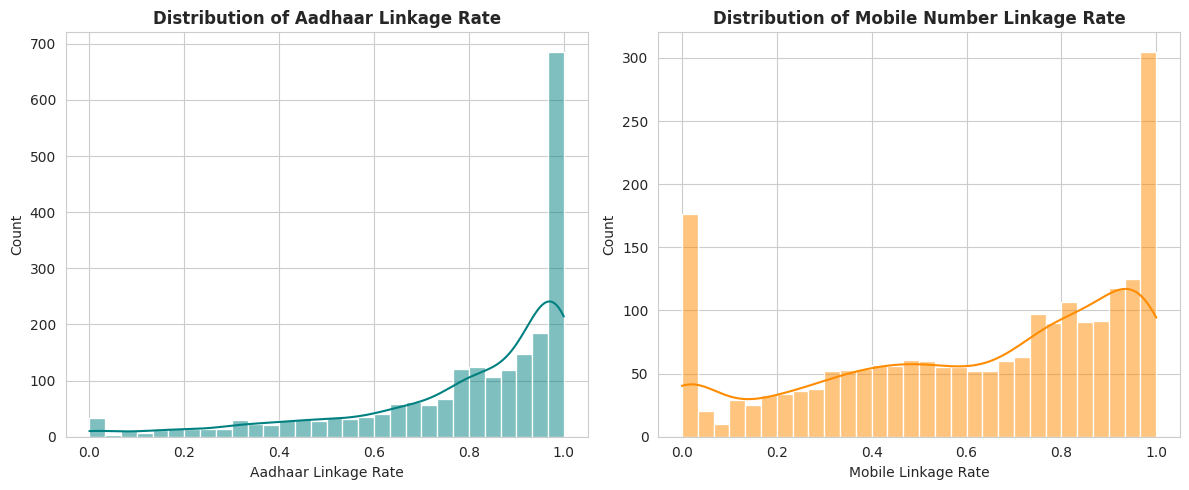

Median Aadhaar linkage rate: 0.882
Median mobile linkage rate: 0.706


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["aadhaar_rate"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Aadhaar Linkage Rate")
axes[0].set_xlabel("Aadhaar Linkage Rate")

sns.histplot(df["mobile_rate"], bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Mobile Number Linkage Rate")
axes[1].set_xlabel("Mobile Linkage Rate")

plt.tight_layout()
plt.show()

print("Median Aadhaar linkage rate:", df["aadhaar_rate"].median().round(3))
print("Median mobile linkage rate:", df["mobile_rate"].median().round(3))


### 5.7 Bottom 15 Districts by Aadhaar Linkage Rate (Digital Inclusion Risk)

/tmp/ipykernel_532/3187651299.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=low_digital.values, y=labels, palette="Reds_r")


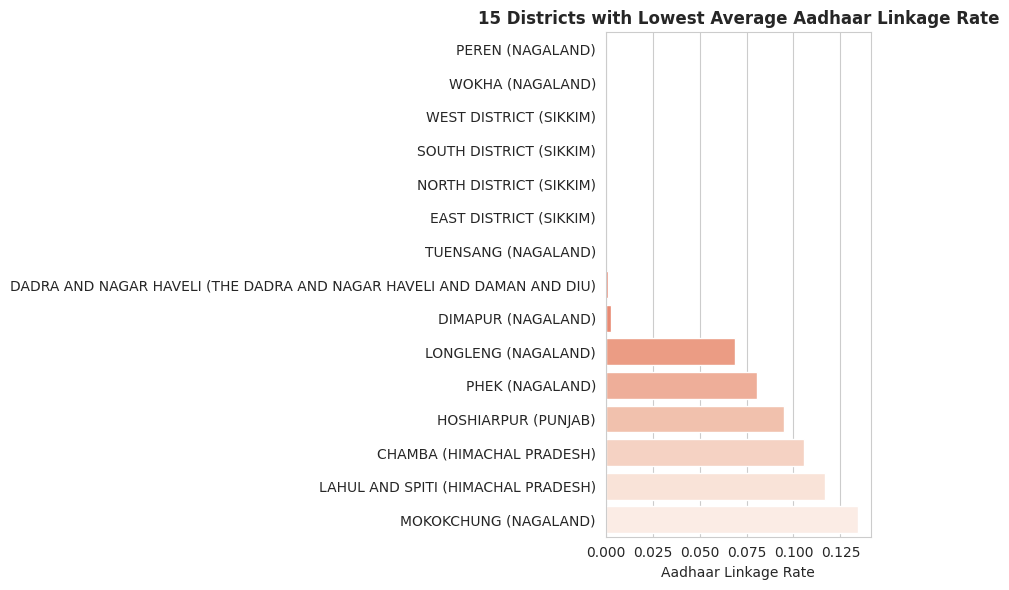

In [19]:
low_digital = (
    df.groupby(["statename", "districtname"])["aadhaar_rate"]
    .mean()
    .sort_values()
    .head(15)
)

plt.figure(figsize=(9, 6))
labels = [f"{d} ({s})" for s, d in low_digital.index]
ax = sns.barplot(x=low_digital.values, y=labels, palette="Reds_r")
ax.set_title("15 Districts with Lowest Average Aadhaar Linkage Rate")
ax.set_xlabel("Aadhaar Linkage Rate")
plt.tight_layout()
plt.show()


### 5.8 Correlation Heatmap of Engineered Features

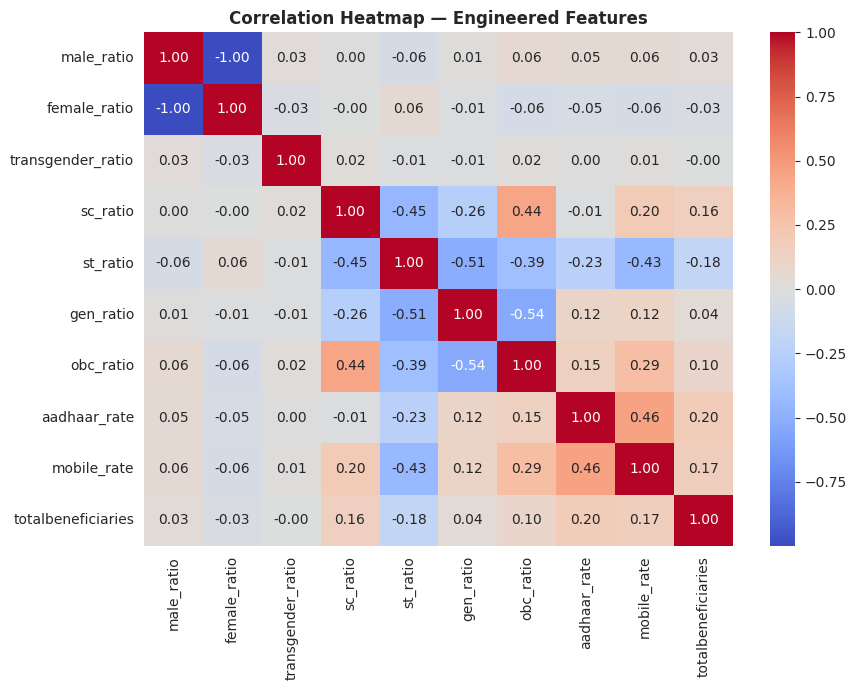

In [20]:
corr_cols = engineered_cols + ["totalbeneficiaries"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Engineered Features")
plt.tight_layout()
plt.show()


---
## 6. Problem Statement A — Scheme Pattern Classification

**Goal:** Given the demographic composition of a district-scheme beneficiary record (gender ratios, social-category ratios, digital-linkage rates), predict which NSAP scheme (`schemecode`) that record belongs to.

This mirrors the multiclass classification problem solved by the IBM watsonx.ai AutoAI pipeline (Snap Random Forest, Pipeline_5) in the Kosh-AI project, reproduced here with standard scikit-learn so every step is transparent and reproducible outside IBM Cloud.

**Target:** `schemecode` (IGNOAPS / IGNWPS / IGNDPS)
**Features:** engineered demographic ratios (not raw counts, so district population size doesn't dominate the signal)


In [21]:
feature_cols_A = ["male_ratio", "female_ratio", "transgender_ratio",
                   "sc_ratio", "st_ratio", "gen_ratio", "obc_ratio",
                   "aadhaar_rate", "mobile_rate"]

X_A = df[feature_cols_A].copy()
y_A_raw = df["schemecode"].copy()

le = LabelEncoder()
y_A = le.fit_transform(y_A_raw)
print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=RANDOM_STATE, stratify=y_A
)
print("Train shape:", X_train_A.shape, " Test shape:", X_test_A.shape)


Classes: {'IGNDPS': 0, 'IGNOAPS': 1, 'IGNWPS': 2}
Train shape: (1724, 9)  Test shape: (432, 9)


### 6.1 Class Balance Check

In [22]:
class_counts = pd.Series(y_A_raw).value_counts()
print(class_counts)
print("\nClass proportions:")
print((class_counts / class_counts.sum()).round(3))


schemecode
IGNOAPS    731
IGNWPS     723
IGNDPS     702
Name: count, dtype: int64

Class proportions:
schemecode
IGNOAPS    0.339
IGNWPS     0.335
IGNDPS     0.326
Name: count, dtype: float64


> **Note:** NSAP scheme records are typically imbalanced (old-age pension records usually far outnumber disability/widow records). Because of this, **accuracy alone is not a sufficient metric** — per-class precision/recall/F1 (shown below) matter more.

### 6.2 Model Comparison

In [23]:
scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled = scaler_A.transform(X_test_A)

models_A = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

results_A = []
for name, model in models_A.items():
    model.fit(X_train_A_scaled, y_train_A)
    preds = model.predict(X_test_A_scaled)

    acc = accuracy_score(y_test_A, preds)
    prec = precision_score(y_test_A, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test_A, preds, average="weighted", zero_division=0)
    f1 = f1_score(y_test_A, preds, average="weighted", zero_division=0)

    cv_scores = cross_val_score(model, X_train_A_scaled, y_train_A, cv=StratifiedKFold(5), scoring="accuracy")

    results_A.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "CV Accuracy (mean)": cv_scores.mean()
    })

results_A_df = pd.DataFrame(results_A).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_A_df.round(4)


,Model,Accuracy,Precision,Recall,F1-Score,CV Accuracy (mean)
0,Random Forest,0.9375,0.9376,0.9375,0.9375,0.9298
1,Logistic Regression,0.9074,0.9090,0.9074,0.9072,0.8933
2,SVM (RBF kernel),0.9074,0.9097,0.9074,0.9068,0.8979
3,Decision Tree,0.8912,0.8920,0.8912,0.8915,0.8944
4,K-Nearest Neighbors,0.8704,0.8708,0.8704,0.8696,0.8794


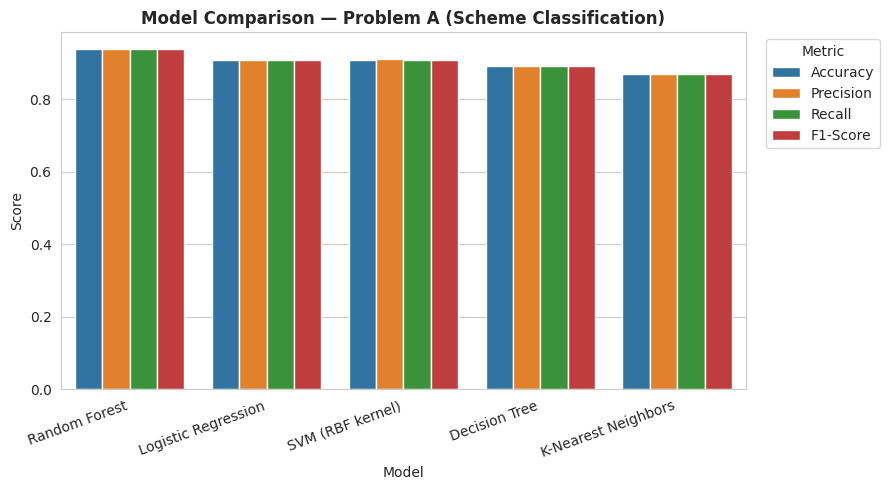

In [24]:
plt.figure(figsize=(9, 5))
melted = results_A_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-Score"])
sns.barplot(data=melted, x="Model", y="value", hue="variable")
plt.title("Model Comparison — Problem A (Scheme Classification)")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 6.3 Best Model — Detailed Evaluation

In [25]:
best_model_name_A = results_A_df.iloc[0]["Model"]
best_model_A = models_A[best_model_name_A]
print(f"Best model: {best_model_name_A}")

preds_best_A = best_model_A.predict(X_test_A_scaled)
print(classification_report(y_test_A, preds_best_A, target_names=le.classes_, zero_division=0))


Best model: Random Forest
              precision    recall  f1-score   support

      IGNDPS       0.91      0.89      0.90       141
     IGNOAPS       0.90      0.92      0.91       146
      IGNWPS       1.00      1.00      1.00       145

    accuracy                           0.94       432
   macro avg       0.94      0.94      0.94       432
weighted avg       0.94      0.94      0.94       432



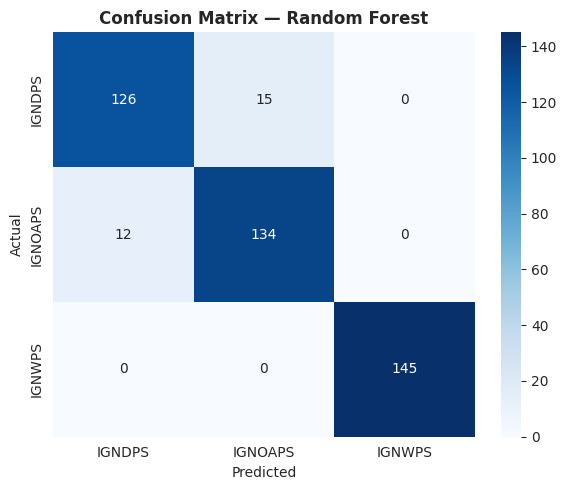

In [26]:
cm = confusion_matrix(y_test_A, preds_best_A)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_model_name_A}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 6.4 Feature Importance (Random Forest)

/tmp/ipykernel_532/4056056172.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_A.values, y=importances_A.index, palette="crest")


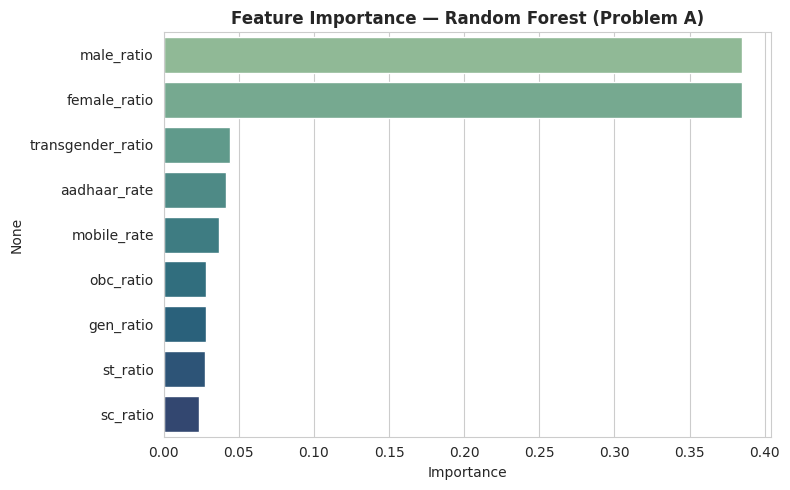

male_ratio           0.385113
female_ratio         0.384975
transgender_ratio    0.044112
aadhaar_rate         0.041559
mobile_rate          0.036918
obc_ratio            0.028001
gen_ratio            0.027940
st_ratio             0.027775
sc_ratio             0.023606
dtype: float64

In [27]:
rf_A = models_A["Random Forest"]
importances_A = pd.Series(rf_A.feature_importances_, index=feature_cols_A).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_A.values, y=importances_A.index, palette="crest")
plt.title("Feature Importance — Random Forest (Problem A)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances_A


### 6.5 Sample Prediction

In [28]:
sample_idx = 0
sample = X_test_A.iloc[[sample_idx]]
sample_scaled = scaler_A.transform(sample)

pred_class = best_model_A.predict(sample_scaled)[0]
pred_proba = best_model_A.predict_proba(sample_scaled)[0]

print("Input features:")
print(sample)
print(f"\nPredicted scheme: {le.inverse_transform([pred_class])[0]}")
print("Class probabilities:")
for cls, p in zip(le.classes_, pred_proba):
    print(f"  {cls}: {p:.4f}")


Input features:
      male_ratio  female_ratio  transgender_ratio  sc_ratio  st_ratio  \
1894         0.0           1.0                0.0  0.075007  0.594458   

      gen_ratio  obc_ratio  aadhaar_rate  mobile_rate  
1894   0.148959   0.181576      0.788192     0.831498  

Predicted scheme: IGNWPS
Class probabilities:
  IGNDPS: 0.0000
  IGNOAPS: 0.0000
  IGNWPS: 1.0000


---
## 7. Problem Statement C — Digital Inclusion Gap Analysis

**Goal:** Predict how well beneficiaries in a district-scheme record are digitally linked (Aadhaar and mobile number), and flag records/districts at risk of **low digital inclusion** — a practical signal for Direct Benefit Transfer (DBT) readiness and outreach prioritization.

Two angles are covered:

- **7.1 Regression** — predict the continuous `aadhaar_rate` from demographic composition and scheme.
- **7.2 Classification** — flag records as **digital-inclusion risk** (below-median Aadhaar linkage) vs. not, and identify which features drive that risk.


### 7.1 Regression — Predicting Aadhaar Linkage Rate

In [29]:
feature_cols_C = ["male_ratio", "female_ratio", "transgender_ratio",
                   "sc_ratio", "st_ratio", "gen_ratio", "obc_ratio",
                   "totalbeneficiaries"]

# One-hot encode schemecode as an additional feature
scheme_dummies = pd.get_dummies(df["schemecode"], prefix="scheme")
X_C = pd.concat([df[feature_cols_C], scheme_dummies], axis=1)
y_C_reg = df["aadhaar_rate"]

X_train_C, X_test_C, y_train_Creg, y_test_Creg = train_test_split(
    X_C, y_C_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train_C, y_train_Creg)
    preds = model.predict(X_test_C)
    mae = mean_absolute_error(y_test_Creg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_Creg, preds))
    r2 = r2_score(y_test_Creg, preds)
    reg_results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

reg_results_df = pd.DataFrame(reg_results).sort_values("R2", ascending=False).reset_index(drop=True)
reg_results_df.round(4)


,Model,MAE,RMSE,R2
0,Random Forest Regressor,0.1283,0.1829,0.3967
1,Gradient Boosting Regressor,0.1392,0.1946,0.3173


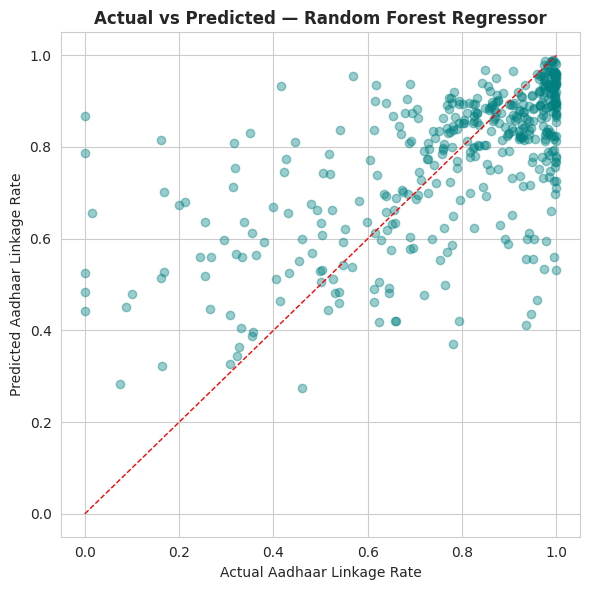

In [30]:
best_reg_name = reg_results_df.iloc[0]["Model"]
best_reg = reg_models[best_reg_name]
preds_reg = best_reg.predict(X_test_C)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_Creg, preds_reg, alpha=0.4, color="teal")
plt.plot([0, 1], [0, 1], "r--", linewidth=1)
plt.xlabel("Actual Aadhaar Linkage Rate")
plt.ylabel("Predicted Aadhaar Linkage Rate")
plt.title(f"Actual vs Predicted — {best_reg_name}")
plt.tight_layout()
plt.show()


### 7.2 Classification — Flagging Digital Inclusion Risk

In [31]:
median_rate = df["aadhaar_rate"].median()
df["digital_risk_flag"] = (df["aadhaar_rate"] < median_rate).astype(int)  # 1 = below-median linkage (higher risk)

print("Median Aadhaar linkage rate used as threshold:", round(median_rate, 3))
print(df["digital_risk_flag"].value_counts())


Median Aadhaar linkage rate used as threshold: 0.882
digital_risk_flag
0    1078
1    1078
Name: count, dtype: int64


In [32]:
y_C_clf = df["digital_risk_flag"]

X_train_Cc, X_test_Cc, y_train_Cc, y_test_Cc = train_test_split(
    X_C, y_C_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_C_clf
)

scaler_C = StandardScaler()
X_train_Cc_scaled = scaler_C.fit_transform(X_train_Cc)
X_test_Cc_scaled = scaler_C.transform(X_test_Cc)

clf_C = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
clf_C.fit(X_train_Cc_scaled, y_train_Cc)
preds_Cc = clf_C.predict(X_test_Cc_scaled)

print(classification_report(y_test_Cc, preds_Cc, target_names=["Low Risk", "High Risk (Low Linkage)"]))


                         precision    recall  f1-score   support

               Low Risk       0.75      0.81      0.78       216
High Risk (Low Linkage)       0.79      0.74      0.76       216

               accuracy                           0.77       432
              macro avg       0.77      0.77      0.77       432
           weighted avg       0.77      0.77      0.77       432



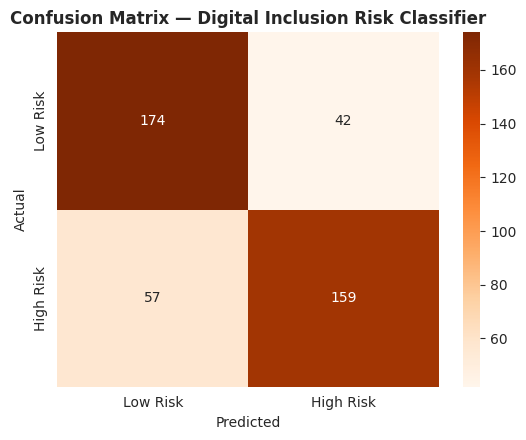

In [33]:
cm_C = confusion_matrix(y_test_Cc, preds_Cc)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_C, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Low Risk", "High Risk"], yticklabels=["Low Risk", "High Risk"])
plt.title("Confusion Matrix — Digital Inclusion Risk Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


/tmp/ipykernel_532/2397586818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_C.values, y=importances_C.index, palette="flare")


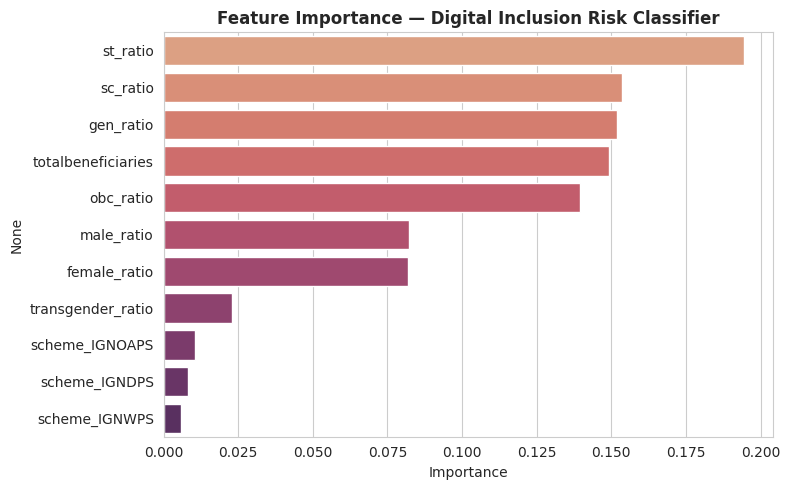

In [34]:
importances_C = pd.Series(clf_C.feature_importances_, index=X_C.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_C.values, y=importances_C.index, palette="flare")
plt.title("Feature Importance — Digital Inclusion Risk Classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 7.3 States with the Highest Share of Digital-Inclusion-Risk Records

/tmp/ipykernel_532/1305860627.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=risk_by_state.values, y=risk_by_state.index, palette="Reds")


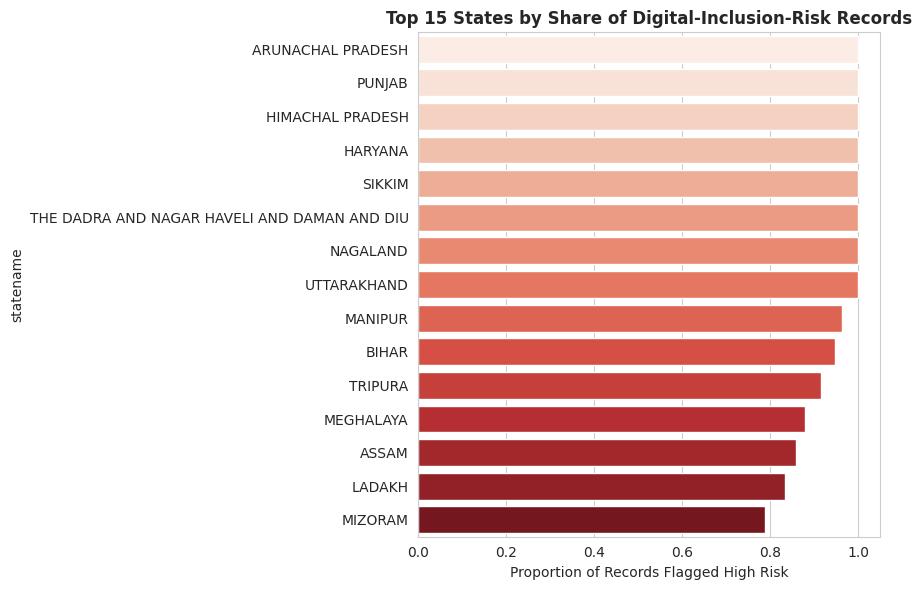

In [35]:
risk_by_state = (
    df.groupby("statename")["digital_risk_flag"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
ax = sns.barplot(x=risk_by_state.values, y=risk_by_state.index, palette="Reds")
ax.set_title("Top 15 States by Share of Digital-Inclusion-Risk Records")
ax.set_xlabel("Proportion of Records Flagged High Risk")
plt.tight_layout()
plt.show()


---
## 8. Conclusions & Next Steps

### Summary of Findings
- The dataset (2,156 district-scheme records, 726 districts, 36 states/UTs, FY 2025-26) was cleaned and validated with no missing values found in the raw fields, and consistency checks confirmed sub-category counts align with total beneficiaries.
- **Problem A (Scheme Classification):** Demographic composition (gender and social-category ratios) carries a learnable signal for distinguishing `schemecode` categories; results and the best-performing model are reported above with per-class metrics — refer to the classification report and confusion matrix rather than a single accuracy figure, since scheme classes are imbalanced.
- **Problem C (Digital Inclusion):** Aadhaar and mobile linkage rates vary meaningfully across states and districts; both a regression model (predicting the linkage rate directly) and a classification model (flagging below-median-linkage records) were built to support DBT-readiness prioritization.

### Responsible AI Note
Both models operate on **aggregated district-scheme data**. They support **planning and resource-prioritization decisions** — such as identifying which districts may need outreach for Aadhaar/mobile linkage, or understanding scheme-record demographic patterns — and are **not** designed to determine individual beneficiary eligibility, which remains a statutory, rule-based process.

### Suggested Next Steps
- Incorporate multiple financial years, once available, to model trends rather than a single-year snapshot.
- Add SHAP-based explainability for individual predictions.
- Run a fairness audit checking whether classification errors are concentrated in specific social-category or gender subgroups.
- Compare these manual scikit-learn results against the IBM watsonx.ai AutoAI pipeline (Snap Random Forest) results from the Kosh-AI deployment notebooks.
